In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("datasets/data.csv")
target = df['class']

df = df.drop(columns='class')

# Faccio uno split 80/10/10
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.1, random_state=42, stratify=target)
val_size = 10/80
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_size, random_state=42, stratify=y_train)


In [32]:
corr = X_train.corr().abs()
columns = corr.columns.tolist()


for i in range(len(columns)):
    for j in range(i+1, len(columns)):
        c = corr.iat[i,j]
        if c >= 0.7:
            f1 = columns[i]
            f2 = columns[j]
            print(f"{f1} - {f2}: {c}")
            



feature_4 - feature_8: 0.8194913739637667
feature_4 - feature_13: 0.8322764729631492


In [33]:
highly_correlated = [['feature_4', 'feature_8', 'feature_13']]

for cols in highly_correlated:
    new_name = "_".join(cols)
    for df in [X_train, X_test, X_val]:
        df[new_name] = df[cols].mean(axis=1)
        df.drop(columns=cols, inplace=True)
        
print(X_train.shape)
print(X_train.columns.to_list())

(2362, 13)
['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_5', 'feature_6', 'feature_7', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_14', 'feature_4_feature_8_feature_13']


In [34]:
from sklearn.feature_selection import SelectKBest
columns = X_train.columns.tolist()
skb = SelectKBest(k=3).set_output(transform='pandas')

X_train = skb.fit_transform(X_train, y_train)
X_test = skb.transform(X_test)
X_val = skb.transform(X_val)

scores = pd.DataFrame({'Features': columns, "Scores": skb.scores_})
print(scores.sort_values(by='Scores', ascending=False))

                          Features       Scores
9                       feature_11  1511.388087
5                        feature_6   297.493464
12  feature_4_feature_8_feature_13   111.576864
7                        feature_9     3.811478
4                        feature_5     1.675321
2                        feature_2     0.742478
3                        feature_3     0.461427
11                      feature_14     0.451758
0                        feature_0     0.272800
1                        feature_1     0.235577
6                        feature_7     0.196904
8                       feature_10     0.133087
10                      feature_12     0.113393


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import numpy as np
from sklearn.metrics import accuracy_score

c2 = 1/np.sqrt(X_train.shape[0])

params = [
    {'C': [1, c2], 'kernel': ['rbf']},
    {'C': [1, c2], 'kernel': ['poly'], 'degree': [3,4]}
]

svc = SVC(probability=True)

gs = GridSearchCV(svc, param_grid=params, scoring='accuracy', cv=3)
gs.fit(X_train, y_train)

print("Miglior classificatore: ", gs.best_params_)
print("Miglior score ottenuto: ", gs.best_score_)

y_test_preds = gs.best_estimator_.predict(X_test)
print("Miglior accuracy in predizione: ", accuracy_score(y_test, y_test_preds))

Miglior classificatore:  {'C': 1, 'kernel': 'rbf'}
Miglior score ottenuto:  0.8873783370635776
Miglior accuracy in predizione:  0.91


In [36]:
import torch 
from torch.utils.data import Dataset
import torchnn as utils

class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        print(self.X.shape)
        self.y = torch.tensor(y, dtype=torch.long)
        print(self.y.shape)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
train_dataloader, val_dataloader, test_dataloader = utils.make_dataloaders(
    MyDataset(np.array(X_train), np.array(y_train)),
    MyDataset(np.array(X_val), np.array(y_val)),
    MyDataset(np.array(X_test), np.array(y_test)),
)

torch.Size([2362, 3])
torch.Size([2362])
torch.Size([338, 3])
torch.Size([338])
torch.Size([300, 3])
torch.Size([300])


/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape e tipo dei campioni: torch.Size([64, 3]), torch.float32
Shape e tipo delle etichette: torch.Size([64]) torch.int64


In [37]:
from torch import nn
class Net(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        w = 128
        self.layers = nn.Sequential(
            nn.Linear(X_train.shape[1], w),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(w,w),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(w,w),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(w, 2),
            nn.LogSoftmax(dim=1)      
        )
        
    def forward(self, x):
        return self.layers(x)
        
        
import copy
class SaveBestModel():
    def __init__(self):
        self.model_state = None
        self.optimizer_state = None
        self.best_accuracy = -1
    
    def __call__(self, accuracy, model, optimizer, epoch, train_loss, val_loss, test_loss, metrics):
        if accuracy > self.best_accuracy:
            self.best_accuracy = accuracy
            self.model_state = copy.deepcopy(model.state_dict())
            self.optimizer_state = copy.deepcopy(optimizer.state_dict())
            self.epoch = epoch
            self.train_loss = train_loss
            self.val_loss = val_loss
            self.test_loss = test_loss
            self.metrics = metrics
            
    def save(self, path):
        torch.save({
            'model_state_dict': self.model_state,
            'optimizer_state_dict': self.optimizer_state,
            'epoch': self.epoch,
            'train_loss': self.train_loss,
            'val_loss': self.val_loss,
            'test_loss': self.test_loss,
            'metrics': self.metrics
        }, path)
model = Net()
device = 'cpu'
model = model.to(device)

optimizer = torch.optim.RMSprop(model.parameters(), centered=True, weight_decay=1e-4, momentum=0.1)
early_stopper = utils.EarlyStopping(patience=5, min_delta=0.01)

In [38]:
from sklearn.metrics import roc_auc_score

def eval_loop(model, 
              dataloader, 
              device, 
              loss_fn):
    model.eval()

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accuracy = 0.0, 0

    y_true = []
    y_pred = []
    y_pred_probs = []
    # context manager che disabilita esplicitamente il calcolo dei gradienti in fase di test
    with torch.no_grad():
        for X, y in dataloader:

            # Spostiamo esplicitamente i tensori sul device di computazione
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            # L'accuracy sul batch si calcola creando il tensore di dimensione pari al batch
            # per cui i massimi argomenti di ogni predizione sono uguali alla classe predetta
            # per il singolo campione, poi convertendo questo tensore di booleani in un vettore
            # binario di tipo float, sommando i valori 1 ed estraendo lo scalare contenuto nel tensore risultato
            accuracy += (pred.argmax(1) == y).type(torch.float).sum().item()

            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.argmax(1).cpu().numpy())
            y_pred_probs.extend(torch.exp(pred).cpu().numpy())

    test_loss /= num_batches
    accuracy /= size            # Per quanto detto prima, l'accuracy media va calcolata sulla dimensione del data set
    auc = roc_auc_score(y_true, np.array(y_pred_probs)[:,1])

    return test_loss, accuracy, auc, (y_true, y_pred, y_pred_probs)


In [39]:
from tqdm import trange
epochs = 30
loss_fn = nn.NLLLoss()

train_loss, validation_loss, test_loss = [], [], []
accuracy = []
metrics = {'auc': []}

train_batches = len(train_dataloader.batch_sampler)
saver = SaveBestModel()
for epoch in range(1, epochs + 1):
    pbar = trange(train_batches)
    pbar.set_description(desc='Epoch {:4d}'.format(epoch))
    
    epoch_train_loss = utils.train_loop(model, train_dataloader, optimizer, device, pbar, loss_fn=loss_fn)
    train_loss.append(epoch_train_loss)
    
    epoch_validate_loss, epoch_accuracy, auc, _ = eval_loop(model, val_dataloader, device, loss_fn=loss_fn)
    validation_loss.append(epoch_validate_loss)
    metrics['auc'].append(auc)
    
    print(f"Train loss: {epoch_train_loss} | Val loss: {epoch_validate_loss}")
    print(f"Auc: {auc} | accuracy: {epoch_accuracy}")
    saver(epoch_accuracy, model, optimizer, epoch, train_loss, validation_loss, test_loss, metrics=metrics)
    
    early_stopper(validation_loss=epoch_validate_loss)
    if early_stopper.early_stop:
        break

saver.save('./prova2024.pth')

Epoch    1: 100%|██████████| 37/37 [00:00<00:00, 387.56it/s]


Train loss: 4.932063557811685 | Val loss: 0.37365466604630154
Auc: 0.9423339518924407 | accuracy: 0.8579881656804734


Epoch    2:   0%|          | 0/37 [00:00<?, ?it/s]/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch    2: 100%|██████████| 37/37 [00:00<00:00, 456.21it/s]


Train loss: 0.35813028466057134 | Val loss: 0.3559912194808324
Auc: 0.9394278911802807 | accuracy: 0.863905325443787


Epoch    3:   0%|          | 0/37 [00:00<?, ?it/s]/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch    3: 100%|██████████| 37/37 [00:00<00:00, 413.67it/s]


...

Train loss: 0.3190166330015337 | Val loss: 0.29057761530081433
Auc: 0.9513322362662372 | accuracy: 0.8905325443786982


Epoch   11:   0%|          | 0/37 [00:00<?, ?it/s]/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch   11: 100%|██████████| 37/37 [00:00<00:00, 438.12it/s]


Train loss: 0.27838955336325877 | Val loss: 0.40955475221077603
Auc: 0.9433493225027135 | accuracy: 0.8668639053254438


Epoch   12:   0%|          | 0/37 [00:00<?, ?it/s]/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch   12: 100%|██████████| 37/37 [00:00<00:00, 431.36it/s]


Train loss: 0.28427230989610824 | Val loss: 0.30442358801762265
Auc: 0.9511571723679143 | accuracy: 0.9023668639053254


/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Text(0.5, 1.0, 'ROC svc vs nn')

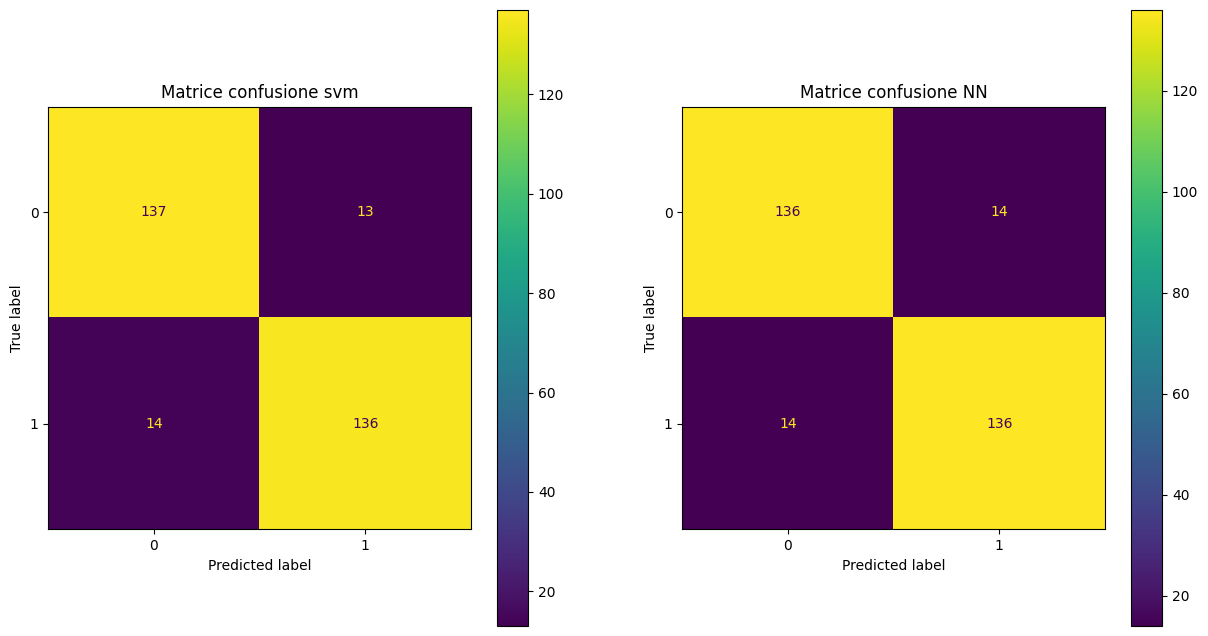

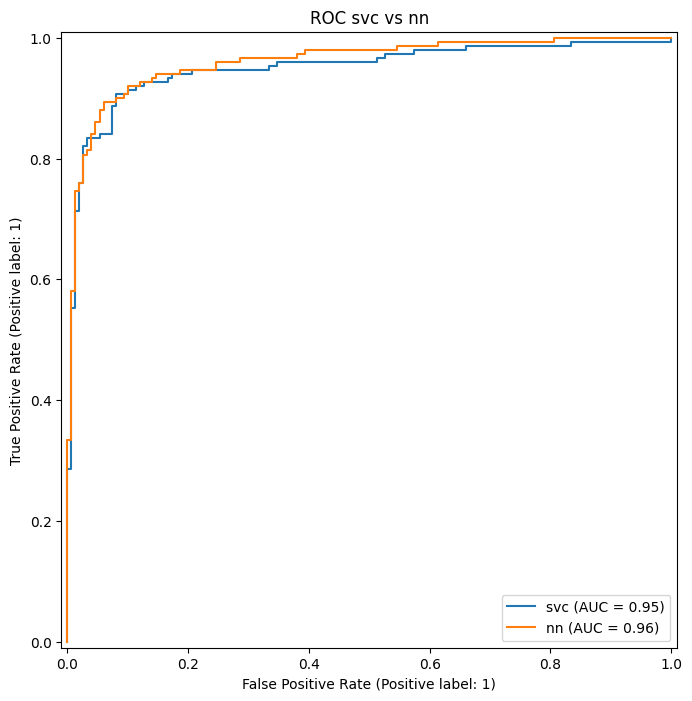

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

model.load_state_dict(saver.model_state)
optimizer.load_state_dict(saver.optimizer_state)

_, accuracy, _, ys = eval_loop(model, test_dataloader, device, loss_fn)
y_true_nn, y_pred_nn, y_pred_probs_nn = ys

fig, ax = plt.subplots(1, 2, figsize=(15,8))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_preds, ax=ax[0])
ax[0].set_title("Matrice confusione svm")

ConfusionMatrixDisplay.from_predictions(y_true_nn, y_pred_nn, ax=ax[1])
ax[1].set_title("Matrice confusione NN")

fig, ax = plt.subplots(1,1, figsize=(15,8))
RocCurveDisplay.from_predictions(y_test, gs.best_estimator_.predict_proba(X_test)[:,1], ax=ax, name='svc')
RocCurveDisplay.from_predictions(y_true_nn, np.array(y_pred_probs_nn)[:,1], ax=ax, name='nn')
ax.set_title("ROC svc vs nn")